# Etapa 1 - Analise Avancada do Baseline HumanEval

Este notebook transforma a primeira etapa do TCC em uma narrativa experimental: baseline, Best-of-N, early stopping, custo computacional, diversidade e hipoteses para activation steering.

## Objetivo da analise

A pergunta aqui nao e apenas se o modelo acerta. Queremos medir quanto acerto adicional vem de gastar mais inferencia e quanto desse custo pode ser recuperado por uma politica de parada com verificador.

Esta celula prepara imports e garante que o pacote local em `src/` seja encontrado mesmo quando o notebook for aberto dentro da pasta `notebooks/`.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

Agora importamos as funcoes analiticas e de visualizacao criadas para o projeto. Manter essas funcoes fora do notebook evita celulas longas e facilita reutilizar a analise quando houver uma run com steering.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from slm_steering.analysis import (
    load_run, attempts_frame, tasks_frame, comparison_frame,
    bon_curve_frame, counterfactual_early_stop_frame,
    diversity_frame, bootstrap_success_table,
)
from slm_steering.visualization import (
    setup_style, plot_best_of_curve, plot_cost_accuracy,
    plot_attempt_heatmap, plot_task_difficulty,
    plot_token_latency, plot_diversity_vs_success,
)

setup_style()

Definimos os caminhos dos dois experimentos ja rodados: Best-of-5 completo e a versao adaptativa com early stopping. A comparacao entre eles isola o efeito economico da parada antecipada.

In [3]:
RUN_DIR = ROOT / "runs" / "phase1_pilot"

best_jsonl = RUN_DIR / "humaneval5_n5_seed1234.jsonl"
best_summary = RUN_DIR / "humaneval5_n5_seed1234_summary.json"

stop_jsonl = RUN_DIR / "humaneval5_n5_seed1234_earlystop.jsonl"
stop_summary = RUN_DIR / "humaneval5_n5_seed1234_earlystop_summary.json"

Carregamos as duas runs como objetos `RunBundle`. A partir daqui, todos os graficos podem ser refeitos para amostras maiores ou para uma futura coluna `steered`.

In [4]:
best_of_5 = load_run(best_jsonl, best_summary, label="best_of_5")
early_stop = load_run(stop_jsonl, stop_summary, label="early_stop")

runs = [best_of_5, early_stop]

A tabela abaixo condensa a mensagem central para slides: a taxa de acerto se manteve, mas a run adaptativa usou menos tentativas e menos tokens.

In [5]:
comparison = comparison_frame(runs)
comparison

,run,tasks,requested_n,adaptive,attempts,solved,pass_at_1,best_of_n,generated_tokens,tokens_to_success_or_budget,tokens_per_solved_task,effective_tokens_per_solved_task,generation_seconds,mean_tokens_per_second,oracle_early_stop_token_savings
0,best_of_5,5,5,False,25,4,0.2,0.8,1497,942,374.25,235.5,181.708467,8.630180,0.370741
1,early_stop,5,5,True,13,4,0.2,0.8,942,942,235.50,235.5,118.154851,8.490887,0.000000


Este grafico coloca acuracia e custo no mesmo plano. A ideia para o TCC e que uma tecnica de steering deve deslocar a fronteira para cima e para a esquerda.

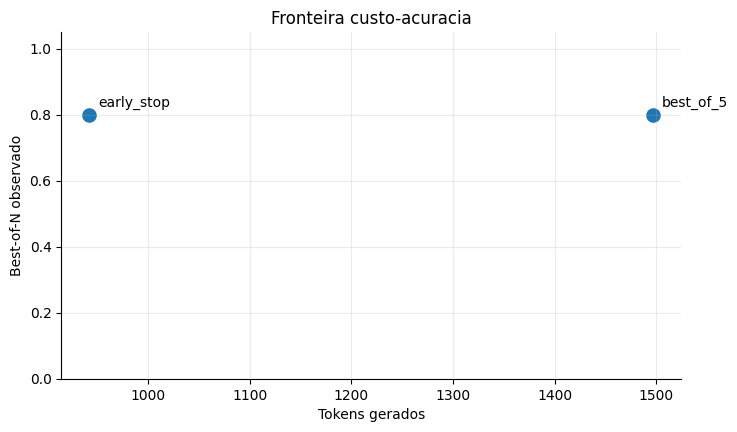

In [6]:
ax = plot_cost_accuracy(comparison)
plt.show()

Agora olhamos a curva Best-of-K. Ela mostra em que ponto amostrar mais respostas deixa de trazer ganho marginal relevante.

In [7]:
curve = pd.concat([bon_curve_frame(best_of_5), bon_curve_frame(early_stop)])
curve

,run,k,observed_best_of_k,pass_at_k_estimate,eligible_tasks
0,best_of_5,1,0.2,0.480000,5
1,best_of_5,2,0.6,0.700000,5
2,best_of_5,3,0.8,0.780000,5
3,best_of_5,4,0.8,0.800000,5
4,best_of_5,5,0.8,0.800000,5
0,early_stop,1,0.2,0.466667,5
1,early_stop,2,0.6,0.666667,4
2,early_stop,3,0.8,0.500000,2
3,early_stop,4,0.8,0.000000,1
4,early_stop,5,0.8,0.000000,1


A visualizacao da curva ajuda a argumentar sobre inference-time scaling: o modelo melhora com mais amostras, mas o retorno marginal pode saturar cedo.

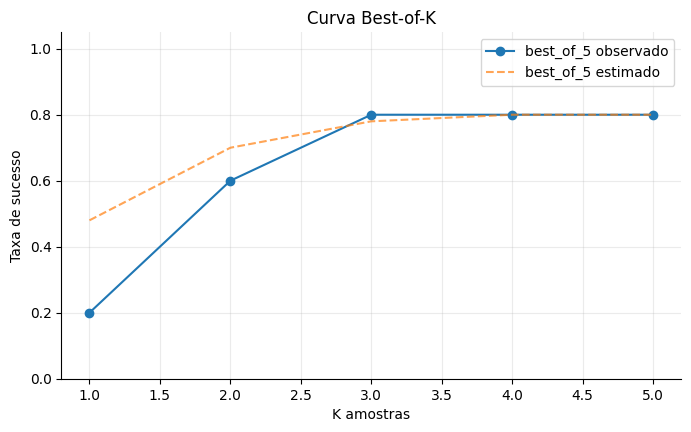

In [8]:
ax = plot_best_of_curve(curve[curve["run"] == "best_of_5"])
plt.show()

O mapa de tentativas mostra onde cada problema foi resolvido. Verde significa tentativa correta; vermelho significa tentativa rejeitada pelo verificador.

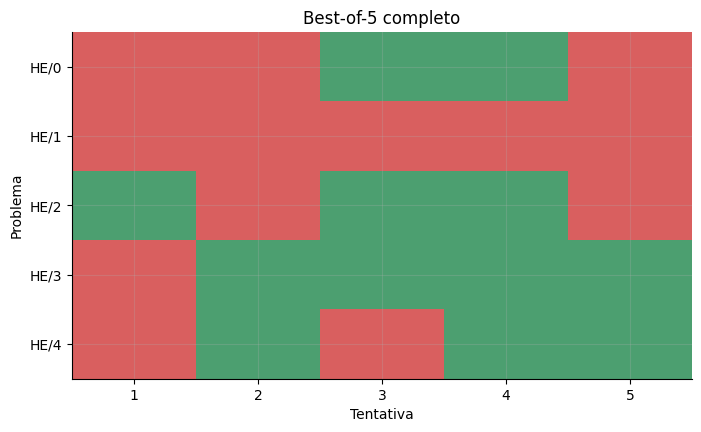

In [9]:
plot_attempt_heatmap(best_of_5.records, title="Best-of-5 completo")
plt.show()

Na run adaptativa, a matriz fica mais curta por problema quando uma solucao correta aparece cedo. Isso representa economia real de inferencia.

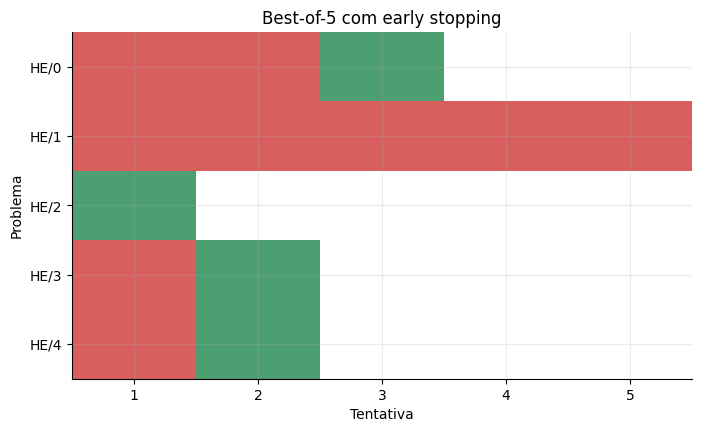

In [10]:
plot_attempt_heatmap(early_stop.records, title="Best-of-5 com early stopping")
plt.show()

A dificuldade empirica por tarefa separa problemas faceis, frageis, parcialmente resolvidos e nao resolvidos. Isso e importante porque steering pode ajudar mais em problemas frageis do que em problemas impossiveis para o modelo.

In [11]:
tasks = tasks_frame(best_of_5)
tasks[["task_id", "solved", "correct_count", "solution_rate", "difficulty"]]

,task_id,solved,correct_count,solution_rate,difficulty
0,HumanEval/0,True,2,0.4,partial
1,HumanEval/1,False,0,0.0,unresolved
2,HumanEval/2,True,3,0.6,partial
3,HumanEval/3,True,4,0.8,partial
4,HumanEval/4,True,3,0.6,partial


Este grafico ordena tarefas pela taxa de solucoes corretas. Ele ajuda a escolher casos para analise qualitativa no texto do TCC.

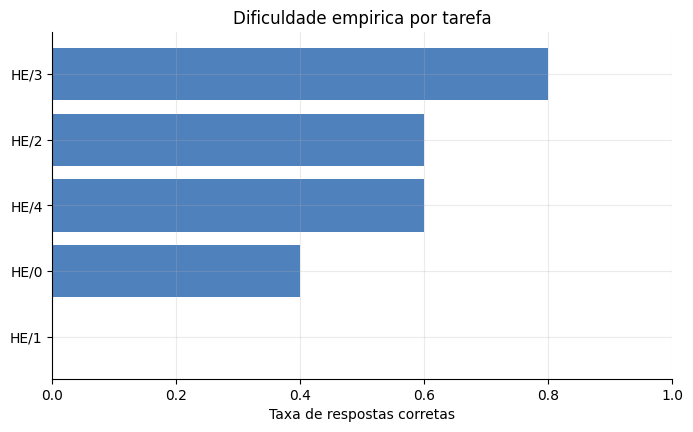

In [12]:
plot_task_difficulty(tasks)
plt.show()

Aqui simulamos o early stopping contrafactual sobre a run completa. Em outras palavras: se tivessemos parado exatamente no primeiro acerto, quanto custo teria sido evitado?

In [13]:
counterfactual = counterfactual_early_stop_frame(best_of_5)
counterfactual[["task_id", "saved_attempts", "saved_tokens", "token_savings_rate"]]

,task_id,saved_attempts,saved_tokens,token_savings_rate
0,HumanEval/0,2,133,0.434641
1,HumanEval/1,0,0,0.000000
2,HumanEval/2,4,66,0.750000
3,HumanEval/3,3,150,0.691244
4,HumanEval/4,3,206,0.517588


Este grafico explicita que a economia nao vem igualmente de todos os problemas. Algumas tarefas sao resolvidas cedo; outras consomem todo o orcamento.

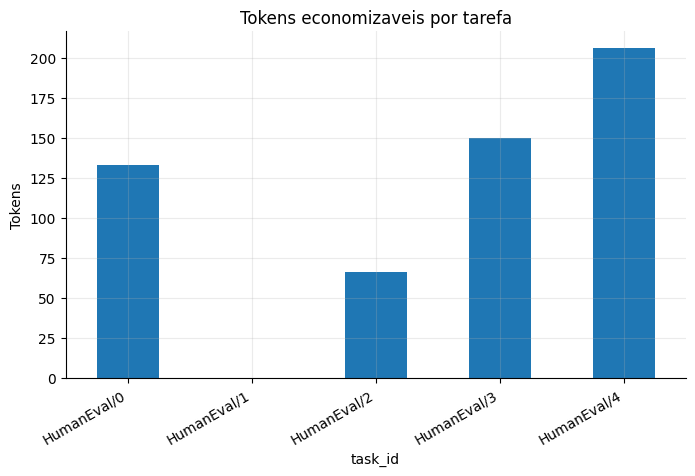

In [14]:
ax = counterfactual.plot.bar(x="task_id", y="saved_tokens", legend=False)
ax.set_title("Tokens economizaveis por tarefa")
ax.set_ylabel("Tokens")
plt.xticks(rotation=30, ha="right")
plt.show()

O custo por tentativa liga o ponto experimental ao hardware. Para um TCC sobre inferencia, tokens e segundos precisam aparecer juntos.

In [15]:
attempts = attempts_frame(best_of_5)
attempts.head()

,run,task_id,entry_point,attempt,seed,passed,generated_tokens,generation_seconds,verification_seconds,total_seconds,tokens_per_second,error_type,raw_chars,candidate_lines
0,best_of_5,HumanEval/0,has_close_elements,1,1234,False,53,10.786140,0.088010,10.874150,4.913713,runtime_error,205,4
1,best_of_5,HumanEval/0,has_close_elements,2,1235,False,54,6.200378,0.078987,6.279365,8.709146,runtime_error,201,6
2,best_of_5,HumanEval/0,has_close_elements,3,1236,True,66,6.773415,0.088539,6.861954,9.743977,passed,265,10
3,best_of_5,HumanEval/0,has_close_elements,4,1237,True,60,7.199310,0.085090,7.284400,8.334132,passed,228,4
4,best_of_5,HumanEval/0,has_close_elements,5,1238,False,73,9.569030,0.233283,9.802313,7.628777,runtime_error,304,9


Neste grafico, pontos verdes sao tentativas corretas e pontos vermelhos sao tentativas rejeitadas. Ele sugere se respostas longas tendem a custar mais sem necessariamente acertar.

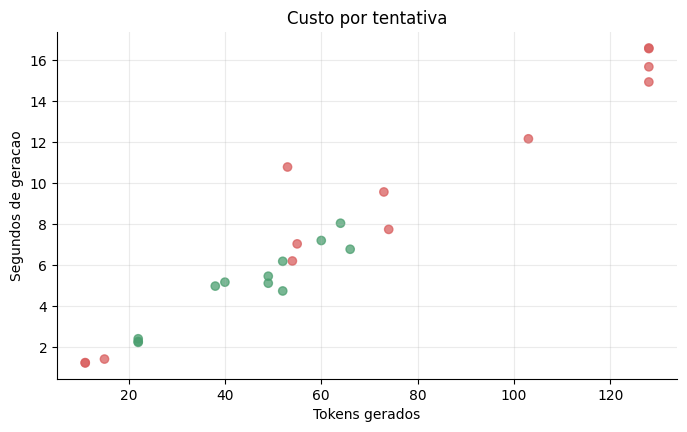

In [16]:
plot_token_latency(attempts)
plt.show()

A diversidade entre codigos e uma ponte direta para activation steering. A hipotese e que steering pode aumentar foco, mas tambem pode reduzir diversidade demais.

In [17]:
diversity = diversity_frame(best_of_5)
diversity[["task_id", "solution_rate", "mean_pairwise_code_distance"]]

,task_id,solution_rate,mean_pairwise_code_distance
0,HumanEval/0,0.4,0.519206
1,HumanEval/1,0.0,0.696702
2,HumanEval/2,0.6,0.441022
3,HumanEval/3,0.8,0.354381
4,HumanEval/4,0.6,0.485561


Este grafico mostra a relacao entre diversidade de respostas e sucesso. Para a fase de steering, queremos evitar colapso de diversidade.

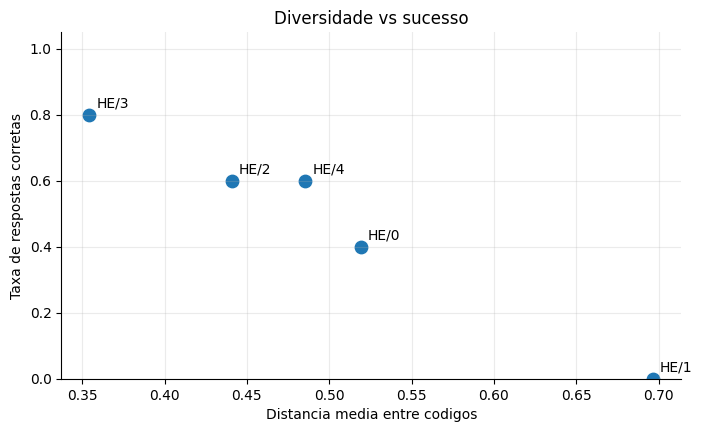

In [18]:
plot_diversity_vs_success(diversity)
plt.show()

Como o piloto tem apenas cinco tarefas, qualquer taxa deve ser apresentada com cautela. O bootstrap abaixo estima intervalos de incerteza para as principais taxas.

In [19]:
ci = bootstrap_success_table(runs)
ci

,run,metric,mean,ci_low,ci_high
0,best_of_5,pass@1 estrito,0.2,0.0,0.6
1,best_of_5,Best-of-N observado,0.8,0.4,1.0
2,early_stop,pass@1 estrito,0.2,0.0,0.6
3,early_stop,Best-of-N observado,0.8,0.4,1.0


Visualizamos esses intervalos para evitar uma narrativa triunfalista com amostra pequena. Em apresentacao, isso mostra maturidade metodologica.

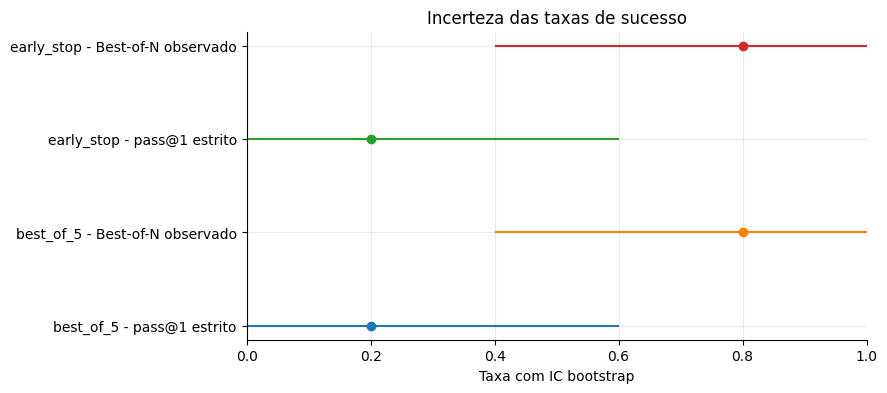

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
for index, row in ci.reset_index(drop=True).iterrows():
    ax.errorbar(row["mean"], index, xerr=[[row["mean"] - row["ci_low"]], [row["ci_high"] - row["mean"]]], fmt="o")
ax.set_yticks(range(len(ci)), labels=ci["run"] + " - " + ci["metric"])
ax.set_xlim(0, 1)
ax.set_xlabel("Taxa com IC bootstrap")
ax.set_title("Incerteza das taxas de sucesso")
plt.show()